In [1]:
#a
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.optimizers import SGD
import matplotlib.pyplot as plt

(trainX, trainy), (testX, testy) = cifar10.load_data()

print(f"Trening podaci: {trainX.shape}, labele: {trainy.shape}")
print(f"Test podaci: {testX.shape}, labele: {testy.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Trening podaci: (50000, 32, 32, 3), labele: (50000, 1)
Test podaci: (10000, 32, 32, 3), labele: (10000, 1)


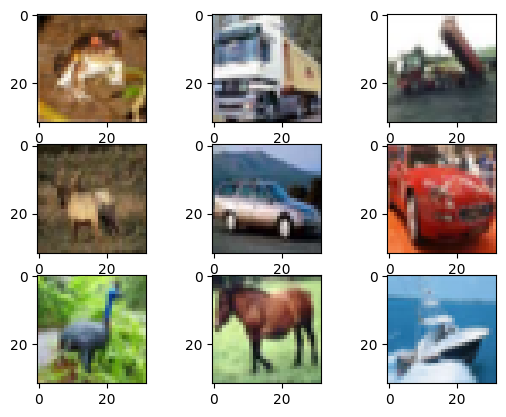

In [2]:
#b
for i in range(9):
    plt.subplot(330 + 1 + i)
    plt.imshow(trainX[i])
plt.show()
# Zaključak: Slike su niske rezolucije (32x32), što je znatno manje od modernih fotografija.
# Niska rezolucija olakšava brzinu treniranja, ali otežava prepoznavanje sitnih detalja.

In [3]:
#c
trainY = to_categorical(trainy)
testY = to_categorical(testy)

trainX = trainX.astype('float32') / 255.0
testX = testX.astype('float32') / 255.0

In [4]:
#d
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def define_model():
    model = Sequential()
    # Prvi blok
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    # Drugi blok
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    # Izlazni blok
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    return model

In [5]:
#e
from keras.optimizers import SGD

def define_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    # Parametri kompajliranja prema uputi e)
    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Inicijalizacija modela
baseline_model = define_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
#f
history = baseline_model.fit(trainX, trainY, epochs=15, batch_size=64, validation_data=(testX, testY))
loss, acc = baseline_model.evaluate(testX, testY)
print(f"Postignuta tačnost: {acc * 100:.2f}%")

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.2514 - loss: 2.0607 - val_accuracy: 0.3574 - val_loss: 1.8137
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3937 - loss: 1.7102 - val_accuracy: 0.4238 - val_loss: 1.6097
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4672 - loss: 1.4975 - val_accuracy: 0.4950 - val_loss: 1.4080
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5103 - loss: 1.3786 - val_accuracy: 0.5285 - val_loss: 1.3236
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5419 - loss: 1.2884 - val_accuracy: 0.5421 - val_loss: 1.2888
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5696 - loss: 1.2134 - val_accuracy: 0.5740 - val_loss: 1.1956
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5978 - loss: 1.1453 - val_accuracy: 0.5856 - val_loss: 1.1602
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6242 - loss: 1.0755 - val_accurac

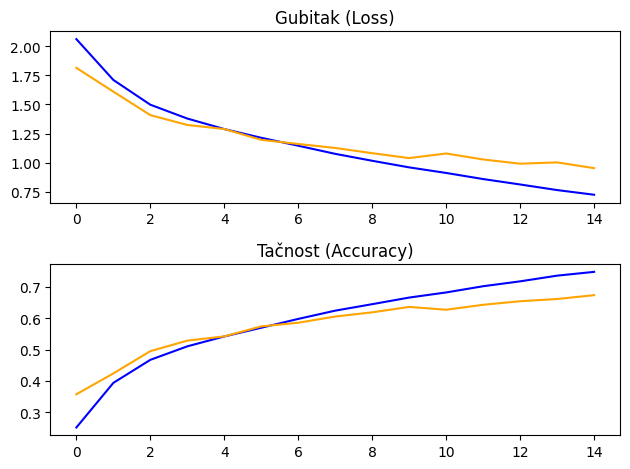

In [7]:
#g
plt.subplot(211)
plt.title('Gubitak (Loss)')
plt.plot(history.history['loss'], color='blue', label='trening')
plt.plot(history.history['val_loss'], color='orange', label='test')

plt.subplot(212)
plt.title('Tačnost (Accuracy)')
plt.plot(history.history['accuracy'], color='blue', label='trening')
plt.plot(history.history['val_accuracy'], color='orange', label='test')
plt.tight_layout()
plt.show()

In [8]:
#h
def define_dropout_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dropout(0.5)) # Dropout 0.5 prema uputi h
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

dropout_model = define_dropout_model()
history_dr = dropout_model.fit(trainX, trainY, epochs=15, batch_size=64, validation_data=(testX, testY))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.2043 - loss: 2.1459 - val_accuracy: 0.3170 - val_loss: 1.9234
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3359 - loss: 1.8544 - val_accuracy: 0.3994 - val_loss: 1.6677
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4106 - loss: 1.6292 - val_accuracy: 0.4715 - val_loss: 1.4796
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4577 - loss: 1.5003 - val_accuracy: 0.4874 - val_loss: 1.4152
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4887 - loss: 1.4171 - val_accuracy: 0.5192 - val_loss: 1.3412
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5164 - loss: 1.3464 - val_accuracy: 0.5530 - val_loss: 1.2536
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5373 - loss: 1.2879 - val_accuracy: 0.5722 - val_loss: 1.2080
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5637 - loss: 1.2285 - val_accuracy:

In [9]:
#i
def define_final_model():
    model = Sequential()
    # Blok 1
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2))
    # Blok 2
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2))
    # Blok 3
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2))
    # Izlazni dio
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(10, activation='softmax'))

    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

final_model = define_final_model()
history_final = final_model.fit(trainX, trainY, epochs=30, batch_size=64, validation_data=(testX, testY))

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.1462 - loss: 2.2583 - val_accuracy: 0.2604 - val_loss: 2.0559
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2567 - loss: 2.0066 - val_accuracy: 0.3103 - val_loss: 1.9093
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3132 - loss: 1.8687 - val_accuracy: 0.3673 - val_loss: 1.7652
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3660 - loss: 1.7345 - val_accuracy: 0.4154 - val_loss: 1.6145
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4040 - loss: 1.6286 - val_accuracy: 0.4294 - val_loss: 1.5651
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4340 - loss: 1.5477 - val_accuracy: 0.4821 - val_loss: 1.4322
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4655 - loss: 1.4725 - val_accuracy: 0.5114 - val_loss: 1.3907
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4904 - loss: 1.4083 - val_accuracy: 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7408 - loss: 0.7347
Konačna tačnost nakon 30 epoha: 74.08%


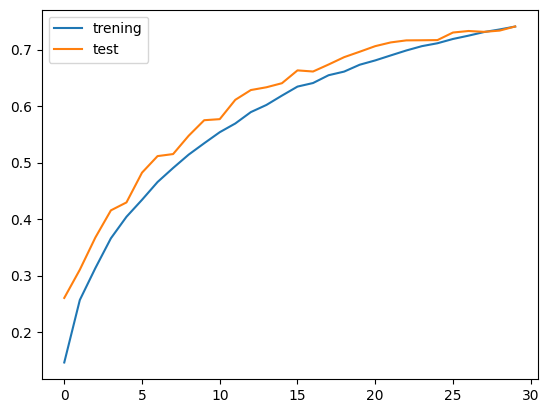

In [10]:
#j
final_loss, final_acc = final_model.evaluate(testX, testY)
print(f"Konačna tačnost nakon 30 epoha: {final_acc * 100:.2f}%")

# Plot finalnog modela
plt.plot(history_final.history['accuracy'], label='trening')
plt.plot(history_final.history['val_accuracy'], label='test')
plt.legend()
plt.show()